In [141]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import fsps
from tqdm import tqdm

from ceridwen.ssps.ssp_data import SSPData
from ceridwen.csp.csp import CSPBasis, fnu2flam

T_UNIV = 13.8  # Gyr, age of the universe
N_T = 100     # number of time steps for SFH

ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')
csp = CSPBasis(ssp_data, dusty=False)

sp = fsps.StellarPopulation(zcontinuous=3, sfh=3)   # tabular SFH, initialise only once!


t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

def gaussian_burst(center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

sfr_bimodal = (gaussian_burst(0.05, 0.03, 1.0) +
               gaussian_burst(11.0, 0.8, 0.7))

zh = jnp.full_like(t, 0.02)  # constant metallicity (Z=0.02)

csp.add_sfh(sfr_bimodal, lookback_time=tau)
csp.add_zh(zh, lookback_time=tau)
spec = csp.get_spectrum()

sp.set_tabular_sfh(age = np.asarray(t), sfr = np.asarray(sfr_bimodal), Z=zh)





wave, spec_fsps = sp.get_spectrum(tage=13.8) 

spec_fsps = fnu2flam(wave, spec_fsps * 1e-23 * 3631.0 ) # convert to Jy if needed



lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


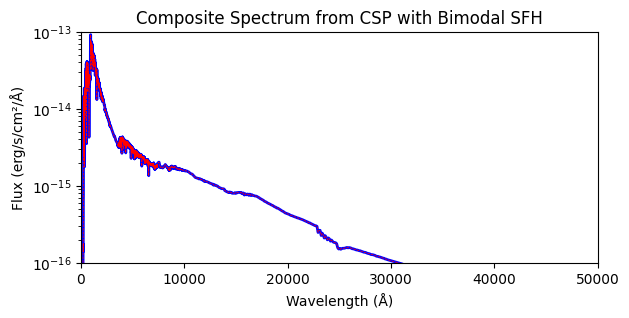

In [142]:
# Plot the resulting spectrum
plt.figure(figsize=(20/3, 3))
plt.plot(csp.wave, fnu2flam(csp.wave, spec*1e-23*3631), lw =2, label='Composite Spectrum', color='blue')
plt.plot(wave, spec_fsps, label='FSPS Spectrum', lw=0.5, color='red', linestyle='--')
plt.yscale('log')
plt.xlim(0, 50000)
plt.ylim(1e-16, 10**-13)
plt.title('Composite Spectrum from CSP with Bimodal SFH')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux (erg/s/cm²/Å)')
plt.show()

# Add dust2 to FSPS

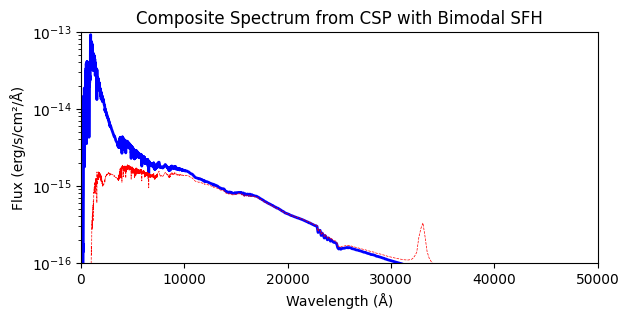

In [143]:
sp.params['dust_type'] = 4
sp.params['dust2'] = 0.5
sp.params['dust_index'] = -0.7

wave, spec_fsps = sp.get_spectrum(tage=13.8) 

spec_fsps = fnu2flam(wave, spec_fsps * 1e-23 * 3631.0 ) # convert to Jy if needed

# Plot the resulting spectrum
plt.figure(figsize=(20/3, 3))
plt.plot(csp.wave, fnu2flam(csp.wave, spec*1e-23*3631), lw =2, label='Composite Spectrum', color='blue')
plt.plot(wave, spec_fsps, label='FSPS Spectrum', lw=0.5, color='red', linestyle='--')
plt.yscale('log')
plt.xlim(0, 50000)
plt.ylim(1e-16, 10**-13)
plt.title('Composite Spectrum from CSP with Bimodal SFH')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux (erg/s/cm²/Å)')
plt.show()


# Add dust2 to ceridwen

In [144]:
from ceridwen.dust import Dust
from sedpy_jax.attenuation_dust import ATTENUATION_LAWS
from pprint import pprint
#pprint(ATTENUATION_LAWS)

In [145]:
dust = Dust(bin_edges=[(0, 10)], laws=['powerlaw'], diffuse_law='kriek_conroy')

print(dust.get_default_fit_params())

{'tau_pow': 1.0, 'alpha': 1.0, 'diffuse_params': {'tau_kc': 1.0, 'dust_index': 0.0}}


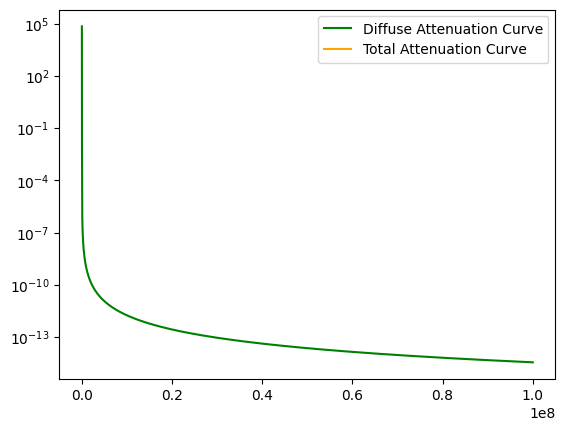

In [146]:
fit_params = {'tau_pow': 0.0, 'alpha': 1.0, 'diffuse_params': {'tau_kc': 0.5, 'dust_index': -0.7}}

attenuation = dust.compute_attenuation(csp.wave, fit_params)
attenuation, diffuse = dust._compute_with_diffuse(csp.wave, fit_params)

plt.plot(csp.wave, diffuse, label='Diffuse Attenuation Curve', color='green')
plt.plot(csp.wave, attenuation[0], label='Total Attenuation Curve', color='orange')
plt.yscale('log')
plt.legend()

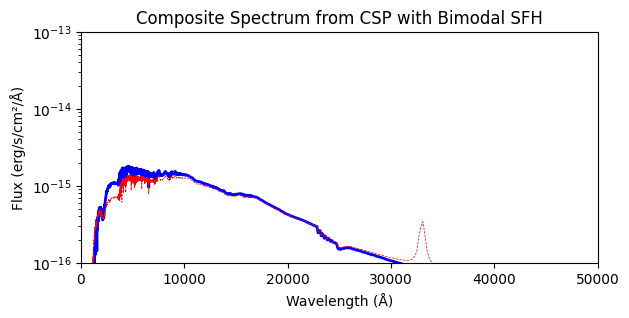

In [147]:

sp.params['dust2'] = 0.5
sp.params['dust1'] = 1
sp.params['dust_index'] = -0.7
sp.params['dust1_index'] = -1


wave, spec_fsps = sp.get_spectrum(tage=13.8) 

spec_fsps = fnu2flam(wave, spec_fsps * 1e-23 * 3631.0 ) # convert to Jy if needed

dust = Dust(bin_edges=[(0, 10)], laws=['powerlaw'], diffuse_law='kriek_conroy')
fit_params = {'tau_pow': 1, 'alpha': 1.0, 'diffuse_params': {'tau_kc': 0.5, 'dust_index': -1}}

attenuation = dust.compute_attenuation(csp.wave, fit_params)
attenuation, diffuse = dust._compute_with_diffuse(csp.wave, fit_params)

spec_dust = spec * np.exp(-diffuse)

# Plot the resulting spectrum
plt.figure(figsize=(20/3, 3))
plt.plot(csp.wave, fnu2flam(csp.wave, spec_dust*1e-23*3631), lw =2, label='Composite Spectrum', color='blue')
plt.plot(wave, spec_fsps, label='FSPS Spectrum', lw=0.5, color='red', linestyle='--')
plt.yscale('log')
plt.xlim(0, 50000)
plt.ylim(1e-16, 10**-13)
plt.title('Composite Spectrum from CSP with Bimodal SFH')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux (erg/s/cm²/Å)')
plt.show()


In [148]:
dust = Dust(bin_edges=[(0, 10)], laws=['powerlaw'])
dust.get_default_fit_params()

{'tau_pow': 1.0,
 'alpha': 1.0,
 'diffuse_params': {'tau_kc': 1.0, 'dust_index': 0.0}}

In [149]:
sp.params['frac_obrun']

0.0

(1, 5994) (5994,)


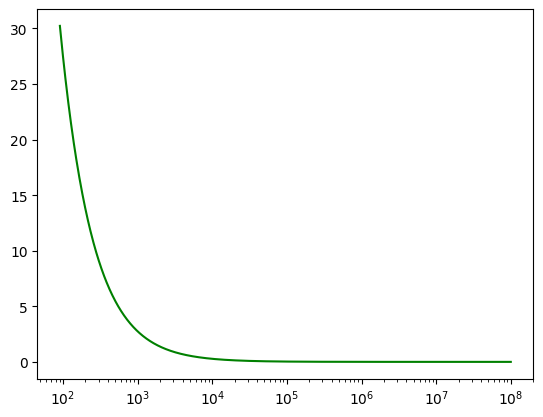

In [150]:
diffdust = 0.5
diffdust_index = -1
young_dust = 0.5
young_dust_index = -1

fit_params = {'tau_pow': young_dust,
                'alpha': -young_dust_index,
                'diffuse_params': {'tau_kc': diffdust, 'dust_index': diffdust_index}}

sp.params['dust_type'] = 4
sp.params['dust2'] = diffdust
sp.params['dust1'] = young_dust
sp.params['dust_index'] = diffdust_index
sp.params['dust1_index'] = young_dust_index
sp.set_tabular_sfh(age = np.asarray(t), sfr = np.asarray(sfr_bimodal), Z=zh)

wave, spec_fsps = sp.get_spectrum(tage=13.8) 
spec_fsps = fnu2flam(wave, spec_fsps * 1e-23 * 3631.0 ) # convert to Jy if needed


dust = Dust(bin_edges=[(0, sp.params['dust_tesc'])], laws=['powerlaw'])
attenuation, diffuse = dust._compute_with_diffuse(csp.wave, fit_params)

print(attenuation.shape, diffuse.shape)
plt.plot(csp.wave, attenuation[0], label='Diffuse Attenuation Curve', color='green')
plt.xscale('log')

In [151]:
specci = csp.get_spectrum()

specci

Array([4.7823448e-13, 4.6874169e-13, 5.0418046e-13, ..., 1.5662279e-13,
       1.5374922e-13, 1.5091957e-13], dtype=float32)

lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


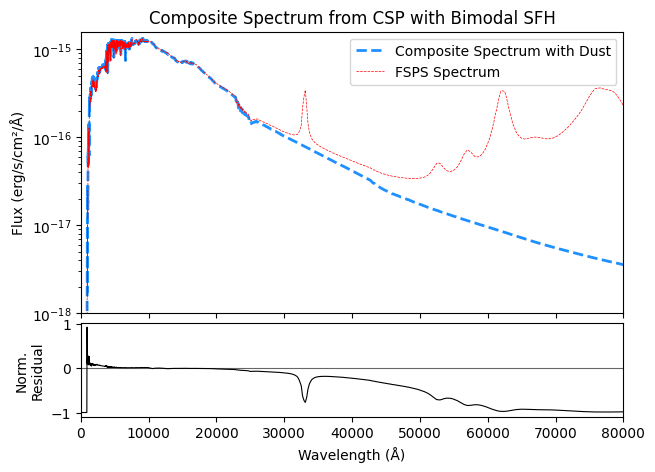

In [152]:
diffdust = 0.5
diffdust_index = -0.7
young_dust = 1.5
young_dust_index = -1


sp.params['dust_type'] = 4
sp.params['dust2'] = diffdust
sp.params['dust1'] = young_dust
sp.params['dust_index'] = diffdust_index
sp.params['dust1_index'] = young_dust_index
sp.set_tabular_sfh(age = np.asarray(t), sfr = np.asarray(sfr_bimodal), Z=zh)

wave, spec_fsps = sp.get_spectrum(tage=13.8) 
spec_fsps = fnu2flam(wave, spec_fsps * 1e-23 * 3631.0 ) # convert to Jy if needed



fit_params = {'tau_pow': young_dust,
                'alpha': -young_dust_index,
                'diffuse_params': {'tau_kc': diffdust, 'dust_index': diffdust_index}}

csp2 = CSPBasis(ssp_data, dusty=True, dust_params={'bin_edges': [(-jnp.inf, sp.params['dust_tesc'] - 9)], 'laws': ['powerlaw']})
csp2.add_sfh(sfr_bimodal, lookback_time=tau)
csp2.add_zh(zh, lookback_time=tau)
spec_dust = csp2.get_spectrum(dust_params=fit_params)

spec_fsps_flam = spec_fsps
spec_dust_flam = fnu2flam(csp2.wave, spec_dust * 1e-23 * 3631)

# Interpolate one spectrum to the other's wavelength grid (just to be safe)
spec_dust_interp = np.interp(wave, csp2.wave, spec_dust_flam)

# Normalised residual: (model - reference) / reference
norm_resid = (spec_dust_interp - spec_fsps_flam) / spec_fsps_flam

# --- Plot ---
fig = plt.figure(figsize=(7, 5))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)

# Top: spectra
ax1 = fig.add_subplot(gs[0])
ax1.plot(csp2.wave, spec_dust_flam, lw=2, label='Composite Spectrum with Dust',
         color='dodgerblue', linestyle='--')
ax1.plot(wave, spec_fsps_flam, label='FSPS Spectrum',
         lw=0.5, color='red', linestyle='--')
ax1.set_yscale('log')
ax1.set_xlim(0, 80000)
ax1.set_ylim(1e-18, 10**-14.8)
ax1.set_ylabel('Flux (erg/s/cm²/Å)')
ax1.set_title('Composite Spectrum from CSP with Bimodal SFH')
ax1.legend(loc='upper right')

# Bottom: residuals
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.axhline(0, color='k', lw=0.8, alpha=0.6)
ax2.plot(wave, norm_resid, color='black', lw=0.8)
ax2.set_xlabel('Wavelength (Å)')
ax2.set_ylabel('Norm.\nResidual')
#ax2.set_xlim(1000, 8000)

# Remove x labels from top plot
plt.setp(ax1.get_xticklabels(), visible=False)

plt.show()

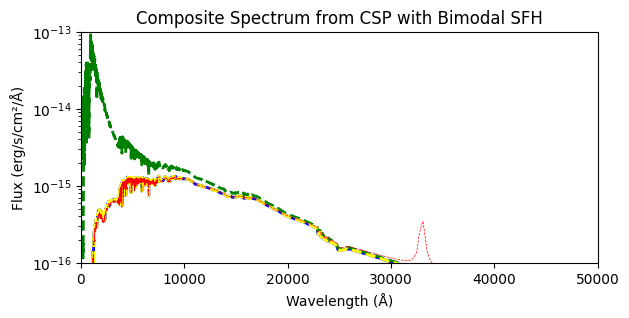

In [153]:
spec_dustfree = csp.get_spectrum_dustfree()

# Plot the resulting spectrum
plt.figure(figsize=(20/3, 3))
plt.plot(csp.wave, fnu2flam(csp.wave, spec_dust*1e-23*3631), lw =2, label='Composite Spectrum', color='blue')
plt.plot(csp.wave, fnu2flam(csp.wave, spec_dustfree*1e-23*3631), lw =2, label='Composite Spectrum without Dust', color='green', linestyle='--')
plt.plot(csp2.wave, fnu2flam(csp2.wave, spec_dust*1e-23*3631), lw =2, label='Composite Spectrum with Dust', color='yellow', linestyle='--')
plt.plot(wave, spec_fsps, label='FSPS Spectrum', lw=0.5, color='red', linestyle='--')
plt.yscale('log')
plt.xlim(0, 50000)
plt.ylim(1e-16, 10**-13)
plt.title('Composite Spectrum from CSP with Bimodal SFH')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux (erg/s/cm²/Å)')
plt.show()

# Implement into CSPBasis

In [107]:
"""
Composite Stellar Population (CSP) Module

This module implements the CSP modeling framework for generating synthetic spectra
from complex star formation and metallicity histories. It provides tools for:

- Building CSPs from Simple Stellar Population (SSP) libraries
- Handling time-dependent star formation and metallicity evolution  
- Computing spectral weights through integration of stellar population models
- Supporting both tabular and parametric stellar formation histories

The core algorithm follows the approach of flexible stellar population synthesis,
where CSPs are constructed by weighting and combining SSP spectra across age
and metallicity grids based on the input star formation and chemical enrichment
histories.

Key classes:
    CSPBasis: Main class for CSP spectrum generation and weight calculation

Key functions:
    add_sfh: Add star formation history to CSP model
    add_zh: Add metallicity evolution history to CSP model  
    intsfwght: Core integration function for stellar formation weights
"""

# JAX imports for high-performance numerical computing
import jax.numpy as jnp  # JAX's numpy-compatible array operations
from jax import jit      # Just-in-time compilation decorator for performance

def fnu2flam(lam, fnu):
    """Convert f_nu [erg/s/cm^2/Hz] to f_lambda [erg/s/cm^2/Å]."""
    c = 2.998e18  # Å/s
    return c * (fnu / (lam**2))

def add_zh(zh, lookback_time=None, forward_time=None, tuniv=13.8):
    """
    Add a star formation history (SFH) for a CSP.
    Parameters:
        zh (array-like): The metallicity at the given ages.
            Example: [0.1, 0.2, 0.3, 0.4]
        
        lookback_time (array-like, optional): Lookback times for the SFH in Gyr.
            Example: [1.0, 2.0, 3.0, 4.0]
        
        forward_time (array-like, optional): Forward times (age of the universe) for the SFH in Gyr.
            Example: [9.8, 10.8, 11.8, 12.8]
        
        tuniv (float, default 13.8): The age of the stellar population (in Gyr) for which to obtain a spectrum.
            Default: 13.8 Gyr

    Returns:
        tuple: A tuple containing:
            - sfh (jnp.ndarray): The star formation history array.
            Example output: jnp.array([0.1, 0.2, 0.3, 0.4])
            
            - sfh_times (jnp.ndarray): The corresponding times (lookback or forward) for the SFH.
            Example output with lookback_time: jnp.array([1.0, 2.0, 3.0, 4.0])
            Example output with forward_time: jnp.array([1.0, 2.0, 3.0, 4.0]) (computed as tuniv - forward_time)

    Usage:
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], lookback_time=[1.0, 2.0, 3.0, 4.0])
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], forward_time= [9.8, 10.8, 11.8, 12.8])
    """
    # Convert metallicity history to JAX array for efficient computation
    zh = jnp.array(zh)  # Ensure zh is a JAX array

    # Process time input - either lookback time (time before present) or forward time (age of universe)
    if lookback_time is not None:
        print('lookback time')  # Debug output for time mode
        lookback_time = jnp.array(lookback_time)
        # Convert from Gyr to years for internal calculations
        zh_times = lookback_time*1e9  
    elif forward_time is not None:
        print('forward time')  # Debug output for time mode  
        forward_time = jnp.array(forward_time)
        # Convert forward time to lookback time: lookback = tuniv - forward_time
        zh_times = tuniv*1e9 - forward_time*1e9  # Compute lookback time from forward time  
        print(zh_times)  # Debug output for computed times
    else:
        # Neither time specification provided - this is an error condition
        raise ValueError("Either 'lookback_time' or 'forward_time' must be provided.")
    
    # Note: This condition seems incorrect - zh_times should never be None at this point
    if zh_times != None:
        print('No times added for metallicity history, use lookback_time or forward_time of SFH')
    
    # Validate that metallicity and time arrays have consistent dimensions
    if zh.shape != zh_times.shape:
        raise ValueError(
            f"Shape mismatch: zh has shape {zh.shape}, but zh_times has shape {zh_times.shape}."
        )
    
    return zh, zh_times


def add_sfh(sfh, lookback_time=None, forward_time=None, tuniv=13.8):
    """
    Add a star formation history (SFH) for a CSP.
    Parameters:
        sfh (array-like): The star formation rate in solar masses per year at the given ages.
            Example: [0.1, 0.2, 0.3, 0.4]
        
        lookback_time (array-like, optional): Lookback times for the SFH in Gyr.
            Example: [1.0, 2.0, 3.0, 4.0]
        
        forward_time (array-like, optional): Forward times (age of the universe) for the SFH in Gyr.
            Example: [9.8, 10.8, 11.8, 12.8]
        
        tuniv (float, default 13.8): The age of the stellar population (in Gyr) for which to obtain a spectrum.
            Default: 13.8 Gyr

    Returns:
        tuple: A tuple containing:
            - sfh (jnp.ndarray): The star formation history array.
            Example output: jnp.array([0.1, 0.2, 0.3, 0.4])
            
            - sfh_times (jnp.ndarray): The corresponding times (lookback or forward) for the SFH.
            Example output with lookback_time: jnp.array([1.0, 2.0, 3.0, 4.0])
            Example output with forward_time: jnp.array([1.0, 2.0, 3.0, 4.0]) (computed as tuniv - forward_time)

    Usage:
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], lookback_time=[1.0, 2.0, 3.0, 4.0])
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], forward_time= [9.8, 10.8, 11.8, 12.8])
    """
    # Convert star formation history to JAX array for efficient computation
    sfh = jnp.array(sfh)  # Ensure sfh is a JAX array

    # Process time input - either lookback time (time before present) or forward time (age of universe)
    if lookback_time is not None:
        print('lookback time')  # Debug output for time mode
        lookback_time = jnp.array(lookback_time)
        # Convert from Gyr to years for internal calculations  
        sfh_times = lookback_time*1e9  

    elif forward_time is not None:
        print('forward time')  # Debug output for time mode
        forward_time = jnp.array(forward_time)
        # Convert forward time to lookback time: lookback = tuniv - forward_time
        sfh_times = tuniv*1e9 - forward_time*1e9  # Compute lookback time from forward time  
        print(sfh_times)  # Debug output for computed times
    else:
        # Neither time specification provided - this is an error condition
        raise ValueError("Either 'lookback_time' or 'forward_time' must be provided.")
    
    # Validate that star formation rate and time arrays have consistent dimensions
    if sfh.shape != sfh_times.shape:
        raise ValueError(
            f"Shape mismatch: sfh has shape {sfh.shape}, but sfh_times has shape {sfh_times.shape}."
        )
    
    
    return sfh, sfh_times

@jit
def intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_broadcasted):
    """
    Compute the integrated star formation weight for CSP modeling.
    
    This function calculates the contribution of stellar populations formed within 
    specific age bins to the overall CSP spectrum. It handles the integration of
    the star formation rate over time intervals, accounting for linear interpolation
    between adjacent time points.
    
    The integration accounts for:
    - Linear interpolation of SFR between time bins (sf_slope term)
    - Proper weighting by formation time and current age
    - Log-linear time scaling typical in stellar population models
    
    Args:
        tlimhi: Upper integration limit in log(age) (younger ages)
        tlimlo: Lower integration limit in log(age) (older ages) 
        a_broadcasted: Linear term coefficient for SFH interpolation
        sf_slope_broadcasted: Slope term for linear SFH interpolation
        logage_broadcasted: Log age of SSP bin being weighted
        
    Returns:
        intsfwght: Integrated star formation weight for the age interval
    """
    # Natural log conversion factor (log10(e)) for mathematical convenience
    loge = jnp.log10(jnp.e)

    # Convert log ages back to linear scale for integration calculations
    exp_tlimlo = 10**tlimlo  # Shape: (i, j) - Linear age at lower limit (older)
    exp_tlimhi = 10**tlimhi  # Shape: (i, j) - Linear age at upper limit (younger)  
    exp_tlimlo_squared = exp_tlimlo**2  # Shape: (i, j) - Squared for quadratic terms
    exp_tlimhi_squared = exp_tlimhi**2  # Shape: (i, j) - Squared for quadratic terms

    # Compute star formation weight at lower integration limit (older ages)
    # b1: Linear term contribution at older boundary
    b1 = a_broadcasted * exp_tlimlo * (logage_broadcasted - tlimlo + loge)
    # c1: Quadratic term contribution from SFH slope at older boundary  
    c1 = sf_slope_broadcasted * exp_tlimlo_squared / 2 * (logage_broadcasted - tlimlo + loge / 2)
    sfwght_lo = b1 + c1  # Total weight contribution at older boundary

    # Compute star formation weight at upper integration limit (younger ages)
    # b2: Linear term contribution at younger boundary
    b2 = a_broadcasted * exp_tlimhi * (logage_broadcasted - tlimhi + loge)
    # c2: Quadratic term contribution from SFH slope at younger boundary
    c2 = sf_slope_broadcasted * exp_tlimhi_squared / 2 * (logage_broadcasted - tlimhi + loge / 2)
    sfwght_hi = b2 + c2  # Total weight contribution at younger boundary

    # Fundamental theorem of calculus: integrated weight = upper_limit - lower_limit
    intsfwght = sfwght_hi - sfwght_lo
    return intsfwght

class CSPBasis:
    """
    A class to wrap the CSP object, providing the spectrum of a CSP for a given SFH.
    """

    def __init__(self, SSPData, tuniv = 13.8, tiny_logt = -10, dusty = True, 
                 dust_params = {'bin_edges': [(0, 10), (10, jnp.inf)], 
                                'laws': ['powerlaw', 'kriek_conroy'], 'diffuse_law': 'kriek_conroy'}, **kwargs):
        """
        Initialize CSPBasis with the given SSPData object and age bounds from gal_t_table.
        
        Parameters:
            SSPData: An object holding SSP data (ages, metallicities, wavelengths, fluxes).
            tuniv: Age of the universe in Gyr (default: 13.8 Gyr)
            tiny_logt: Minimum lookback time in log(years) to prevent numerical issues
            **kwargs: Additional keyword arguments (not used here, but available for future extensions).
        """
        
        # Extract and convert SSP data to JAX arrays for efficient computation
        self.flux = jnp.array(SSPData.ssp_flux)        # SSP flux array: shape (n_metallicity, n_age, n_wavelength)
        self.wave = jnp.array(SSPData.ssp_wave)        # Wavelength grid in Angstroms: shape (n_wavelength,)
        self.ages = jnp.array(SSPData.ssp_lg_age_gyr)  # SSP ages in log10(Gyr): shape (n_age,)
        self.zmet = jnp.array(SSPData.ssp_lgmet)       # SSP metallicities in log10(Z/Zsun): shape (n_metallicity,)
        
        # Convert log metallicities to linear scale for interpolation calculations
        self.zlegend = 10**jnp.array(SSPData.ssp_lgmet)  # Linear metallicity scale: shape (n_metallicity,)

        # Convert SSP age grid from log(Gyr) to log(yr) for internal time calculations
        # This standardizes time units throughout the CSP calculations
        self.time_full = self.ages + 9  # Convert from log(Gyr) to log(yr): log10(Gyr) + log10(1e9) = log10(yr)
        
        # Universe age and numerical precision parameters
        self.tuniv = tuniv        # Age of the Universe in Gyr (cosmological parameter)
        self.tiny_logt = tiny_logt  # Smallest lookback time we accept in log(years) to prevent numerical issues
        if dusty == False:
            self.get_spectrum = self.get_spectrum_dustfree
            self.get_spectrum_direct = self.get_spectrum_direct_dustfree
        else:
            self.get_spectrum = self.get_spectrum_dusty
            #self.get_spectrum_direct = self.get_spectrum_direct_dusty
            self.dust = Dust(**dust_params)
            self.bin_low = jnp.array([edge[0] for edge in self.dust.bin_edges])
            self.bin_high = jnp.array([edge[1] for edge in self.dust.bin_edges])

    def __repr__(self):
        """
        Provide a string representation of the CSPBasis object.
        """
        repr_str = (
            f"<CSPBasis Object>\n"
            f"-----------------------------------\n"
            f"Universe Age (tuniv): {self.tuniv} Gyr\n"
            f"Tiny Log Time (tiny_logt): {self.tiny_logt}\n"
            f"Number of SSP Ages: {len(self.ages)}\n"
            f"Number of SSP Metallicities: {len(self.zmet)}\n"
            f"Wavelength Range: {self.wave.min()} - {self.wave.max()} Å\n"
        )
        
        if hasattr(self, "sfh"):
            repr_str += (
                f"Star Formation History:\n"
                f"  SFH Times (lookback): {self.sfh_times}\n"
                f"  SFH Values: {self.sfh}\n"
            )
        else:
            repr_str += "Star Formation History: Not added yet\n"
        
        if hasattr(self, "spectrum"):
            repr_str += "Spectrum: Computed\n"
        else:
            repr_str += "Spectrum: Not computed yet\n"

        return repr_str

    def add_sfh(self, sfh, lookback_time=None, forward_time=None, tuniv=13.8):
        """
        Add a star formation history to the CSP.

        Parameters:
            sfh: The star formation rate at the given ages.
            lookback_time: Array of lookback times for the SFH in Gyr.
            forward_time: Array of forward times (age of the universe) for the SFH in Gyr.
            tuniv: The age of the universe in Gyr.
        """
        sfh, sfh_times = add_sfh(sfh, lookback_time = lookback_time, forward_time = forward_time, tuniv=tuniv)  # Use the JIT-compiled pure function
        self.sfh = sfh
        self.sfh_times = sfh_times

    def add_zh(self, zh, lookback_time=None, forward_time=None, tuniv=13.8):
        """
        Add a metallicity history to the CSP.

        Parameters:
            zh: The metallicity at the given ages.
            lookback_time: Array of lookback times for the SFH in Gyr.
            forward_time: Array of forward times (age of the universe) for the SFH in Gyr.
            tuniv: The age of the universe in Gyr.
        """
        zh, zh_times = add_zh(zh=zh, lookback_time = lookback_time, forward_time = forward_time, tuniv=tuniv)  # Use the JIT-compiled pure function
        #check that the metallicity history is the same length as the SFH
        if self.sfh_times.shape != zh_times.shape:
            raise ValueError("The metallicity history must have the same length as the SFH.")
        self.sfh_times = zh_times
        self.zh = zh
    
    def change_history(self, sfh=None, zh=None):
        """
        Change the star formation history or metallicity history of the CSP.
        
        Parameters:
            sfh: New star formation history to set.
            zh: New metallicity history to set.
        """
        self.sfh = sfh
        self.zh = zh

    def get_spectrum_dustfree(self):
        """
        Get the spectrum of the CSP for the given SFH. SFH (and optionally zh) must be added to the CSP object using the 'add_sfh' method.
        """
    
        total_weights = self.calculate_ssp_weights()
        
        spectrum = jnp.sum(total_weights[:, :, None] * self.flux, axis=(0,1))  # Shape: (n_wave,)
        self.spectrum = spectrum / (len(self.sfh) - 1) # Normalize by the number of time bins

        return self.spectrum
    

    def get_spectrum_dusty(self, dust_params):

        attenuation, diffuse = self.dust._compute_with_diffuse(self.wave, dust_params)

        is_in_bin = (self.ages[:, None] >= self.bin_low[None, :]) & (self.ages[:, None] < self.bin_high[None, :])
        bin_indices = jnp.argmax(is_in_bin, axis=1)

        self.has_bin = jnp.any(is_in_bin, axis=1)
        has_bin = self.has_bin

        print(bin_indices)

        self.attenuation_matrix = jnp.where(has_bin[:, None], jnp.exp(-attenuation[bin_indices]), jnp.ones_like(attenuation[0]))

        dusty_flux = self.flux * self.attenuation_matrix[None, :, :]  # Apply attenuation to SSP fluxes

        total_weights = self.calculate_ssp_weights()
        spectrum_dust = jnp.sum(total_weights[:, :, None] * dusty_flux, axis=(0,1))

        # --- 6) Apply diffuse attenuation at the end
        self.spectrum = spectrum_dust * jnp.exp(-diffuse)/ (len(self.sfh) - 1)  # Normalize by the number of time bins

        return self.spectrum

    def calculate_ssp_weights(self):
        """
        Calculate SSP weights for CSP spectrum generation.
        
        This is the core method that computes how much each SSP (defined by age and metallicity)
        contributes to the final CSP spectrum based on the star formation and metallicity histories.
        
        The algorithm:
        1. Interpolates SFH linearly between time bins
        2. Computes mass formed in each time interval  
        3. Distributes this mass across SSP age bins via integration
        4. Handles metallicity evolution through linear interpolation
        
        Dimensions: i = number of SFH time bins, j = number of SSP age bins
        
        Returns:
            total_weights: Array of SSP weights, shape depends on metallicity history:
                         - No metallicity history: (1, n_age)
                         - With metallicity history: (n_metallicity, n_age)
        """
        if not hasattr(self, "sfh"):
            raise ValueError("Please add an SFH to the CSP object using the 'add_sfh' method.")
        
        # Ensure SFH values are positive to avoid numerical issues
        self.sfh = jnp.clip(self.sfh, 1e-30, None)  # Ensure SFH is non-negative
        # === TIME BINNING AND SFH INTERPOLATION SETUP ===
        # Define time intervals from the SFH grid
        t1 = self.sfh_times[1:] # Beginning of time intervals (older times) - shape: (i,)
        t2 = self.sfh_times[:-1] # End of time intervals (younger times) - shape: (i,)
        
        # Compute slope for linear interpolation of SFH between adjacent points
        # This allows smooth SFH evolution within each time bin rather than step functions
        sf_slope = jnp.diff(self.sfh) / ((t1 - t2) * self.sfh[1:])  # Shape: (i,) - Normalized SFH slope

        # === TIME CLIPPING AND MASS CALCULATION ===
        # Clip times to physically valid range to avoid extrapolation beyond SSP grid
        tq = jnp.clip(t1, 10**self.tiny_logt, 10**self.time_full[-1])  # Shape: (i,) - Clipped older times
        tage = jnp.clip(t2, 10**self.tiny_logt, 10**self.time_full[-1]) # Shape: (i,) - Clipped younger times
        sf_trunc = tage - tq  # Shape: (i,) - Effective time interval after clipping
        
        # Calculate total stellar mass formed in each time interval
        # Accounts for linear SFH variation within the interval via trapezoidal rule
        m2 = (
                self.sfh[1:]  # SFR at younger edge of interval
                * (1 + sf_slope / 2.0 * (tage + tq - 2 * t1))  # Correction for linear SFH slope
                * sf_trunc  # Multiply by time interval duration
            )  # Shape: (i,) - Total stellar mass formed in each interval

        # Calculate parameters for linear SFH interpolation within integration
        tprime = jnp.maximum(0.0, tage - sf_trunc)  # Shape: (i,) - Time offset for slope calculation
        a = 1 - sf_slope * tprime  # Shape: (i,) - Linear interpolation coefficient

        # SSP-related computations
        ssp_dt = jnp.diff(self.time_full)  # Time intervals in SSP (shape: (107,))
        logage_lft = self.time_full[1:]    # Left edge of log-age bins (shape: (107,))
        logage_rght = self.time_full[:-1]  # Right edge of log-age bins (shape: (107,))

        # Broadcasting integration limits
        tq_broadcasted = jnp.log10(tq)[:, None]  # Expand tq for broadcasting (shape: (9, 1))
        tage_broadcasted = jnp.log10(tage)[:, None]  # Expand tage for broadcasting (shape: (9, 1))

        # Compute integration limits with broadcasting
        tlimlo = jnp.clip(logage_lft[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (9, 107)
        tlimhi = jnp.clip(logage_rght[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (9, 107)

        # Mask computation
        j_indices = jnp.arange(len(self.time_full))  # Indices for SSP bins (shape: (108,))
        jmin = jnp.clip(jnp.searchsorted(self.time_full, jnp.log10(t1)) - 1, 0, len(self.time_full) - 1)  # Shape: (9,)
        jmax = jnp.clip(jnp.searchsorted(self.time_full, jnp.log10(t2)) + 2, 0, len(self.time_full) - 1)  # Shape: (9,)

        # Create mask for relevant SSP bins
        mask = (j_indices >= jmin[:, None]) & (j_indices < jmax[:, None])  # Shape: (9, 108)
        mask_lft = mask[:, 1:]  # Mask for left edges (shape: (9, 107))
        mask_rght = mask[:, :-1]  # Mask for right edges (shape: (9, 107))

        # Boadcast bin edges
        logage_lft_broadcasted = logage_lft[None, :]  # Shape: (1, j), broadcast to (i, j)
        logage_rght_broadcasted = logage_rght[None, :]  # Shape: (1, j), broadcast to (i, j)

        a_broadcasted = a[:, None]  # Shape: (i, 1), broadcast to (i, j)
        sf_slope_broadcasted = sf_slope[:, None]  # Shape: (i, 1), broadcast to (i, j)

        # Left weights  
        intsfwght_lft = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_lft_broadcasted)
        tmp_weights_lft = jnp.zeros_like(intsfwght_lft) - intsfwght_lft / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_lft = jnp.where(mask_lft, tmp_weights_lft, 0.0)

        # Right weights
        intsfwght_rght = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_rght_broadcasted)
        tmp_weights_rght = jnp.zeros_like(intsfwght_rght) + intsfwght_rght / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_rght = jnp.where(mask_rght, tmp_weights_rght, 0.0)

        # Combine left and right weights
        result = jnp.zeros((tmp_weights_lft.shape[0], tmp_weights_lft.shape[1]+1))  
        w1 = result.at[:, :-1].add(tmp_weights_lft).at[:, 1:].add(tmp_weights_rght) # Shape: (i, j)

        m1 = jnp.sum(w1, axis=1) #shape (9,)

        sfh_weights = w1 * (m2[:, None] / m1[:, None])  # Shape: (j,)
        
        if not hasattr(self, "zh"):
            total_weights = sfh_weights.sum(axis=0)
            total_weights = total_weights[None, :]
        else:
            zbin = (self.zh[:-1] + self.zh[1:]) / 2 # Shape: (9,)  # Compute metallicity bin (zbin) from a simple average of adjacent metallicities
            k = jnp.clip(jnp.searchsorted(self.zlegend, zbin) - 1, 0, len(self.zlegend) - 2)  # Shape: (i,)
            bin_size = jnp.log10(self.zlegend[k + 1]) - jnp.log10(self.zlegend[k])  # Shape: (i,)

            dz = (jnp.log10(zbin) - jnp.log10(self.zlegend[k])) / bin_size  # Shape: (i,)
            dz = jnp.clip(dz, -1.0, 1.0)  # Clamping dz to avoid extrapolation

            total_weights = jnp.zeros((len(self.sfh_times)-1, len(self.zlegend), len(self.ages)))

            total_weights = total_weights.at[:, k].add((1 - dz[:, None]) * sfh_weights)
            total_weights = total_weights.at[:, k + 1].add(dz[:, None] * sfh_weights)
            total_weights = total_weights.sum(axis=0)#/(len(self.sfh_times)-1)  # Shape: (n_z, n_time)

            

            # See how much is going into each z bin:
            z_weights = jnp.sum(total_weights, axis=(1))  # shape (n_z,)
            
                
        self.ssp_weights = total_weights
        self.mass_formed = m2
        self.m1 = m1    
        self.m2 = m2
        self.w1 = w1
        
        return total_weights
    
    def get_spectrum_direct_dustfree(self, sfh, zh):
        """
        Get the spectrum of the CSP for the given SFH. SFH (and optionally zh) must be added to the CSP object using the 'add_sfh' method.
        """
    
        total_weights = self.calculate_ssp_weights_direct( sfh = sfh, zh = zh)
        
        spectrum = jnp.sum(total_weights[:, :, None] * self.flux, axis=(0,1))  # Shape: (n_wave,)

        return spectrum / (len(sfh) - 1)

    def calculate_ssp_weights_direct(self, sfh, zh):
        """
        Calculate SSP weights directly from input SFH and metallicity history.
        
        This is the core computational method that implements the CSP algorithm
        without requiring the histories to be stored as object attributes.
        
        Parameters:
            sfh: Star formation history array
            zh: Metallicity history array
            
        Returns:
            total_weights: SSP weights array (n_metallicity, n_age)
        """

        sfh = jnp.clip(sfh, 1e-30, None)  # Ensure SFH is non-negative

        # === TIME BINNING SETUP (same logic as calculate_ssp_weights) ===
        # Use the time grid stored in the object but operate on input SFH arrays directly
        t1 = self.sfh_times[1:]  # Beginning of time intervals (older times) - shape: (i,)
        t2 = self.sfh_times[:-1]  # End of time intervals (younger times) - shape: (i,)
        
        # Compute slope for linear interpolation using input SFH (not self.sfh)
        sf_slope = jnp.diff(sfh) / ((t1 - t2) * sfh[1:])  # Shape: (i,) - SFH slope per interval
        
        # === TIME CLIPPING AND MASS CALCULATION ===
        # Clip integration times to valid SSP grid range (same logic as calculate_ssp_weights)
        tq = jnp.clip(t1, 10**self.tiny_logt, 10**self.time_full[-1])  # Shape: (i,) - Clipped older times
        tage = jnp.clip(t2, 10**self.tiny_logt, 10**self.time_full[-1]) # Shape: (i,) - Clipped younger times
        sf_trunc = tage - tq  # Shape: (i,) - Effective time interval after clipping
        
        # Calculate stellar mass formed using input SFH (key difference: uses sfh parameter, not self.sfh)
        m2 = (sfh[1:]  # Use input SFH array instead of self.sfh
                * (1 + sf_slope / 2.0 * (tage + tq - 2 * t1))  # Trapezoidal rule correction
                * sf_trunc  # Time interval duration
            )  # Shape: (i,) - Stellar mass formed per time interval

        # Linear interpolation parameters for SFH integration
        tprime = jnp.maximum(0.0, tage - sf_trunc)  # Shape: (i,) - Time offset for slope calculation
        a = 1 - sf_slope * tprime  # Shape: (i,) - Linear interpolation coefficient

        # === REMAINDER OF ALGORITHM IDENTICAL TO calculate_ssp_weights ===
        # The following sections implement the same SSP weight calculation algorithm:
        # 1. SSP grid preparation 
        # 2. Integration limit setup and broadcasting
        # 3. Efficiency masking for sparse operations
        # 4. Weight integration using intsfwght function
        # 5. Edge contribution combination via finite differences
        # 6. Mass normalization
        # 7. Metallicity interpolation (using input zh instead of self.zh)
        # See calculate_ssp_weights method for detailed comments on each section
        
        # SSP-related computations
        ssp_dt = jnp.diff(self.time_full)  # Time intervals in SSP (shape: (107,))
        logage_lft = self.time_full[1:]    # Left edge of log-age bins (shape: (107,))
        logage_rght = self.time_full[:-1]  # Right edge of log-age bins (shape: (107,))

        # Broadcasting integration limits
        tq_broadcasted = jnp.log10(tq)[:, None]  # Expand tq for broadcasting (shape: (9, 1))
        tage_broadcasted = jnp.log10(tage)[:, None]  # Expand tage for broadcasting (shape: (9, 1))

        # Compute integration limits with broadcasting
        tlimlo = jnp.clip(logage_lft[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (9, 107)
        tlimhi = jnp.clip(logage_rght[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (9, 107)

        # Mask computation
        j_indices = jnp.arange(len(self.time_full))  # Indices for SSP bins (shape: (108,))
        jmin = jnp.clip(jnp.searchsorted(self.time_full, jnp.log10(t1)) - 1, 0, len(self.time_full) - 1)  # Shape: (9,)
        jmax = jnp.clip(jnp.searchsorted(self.time_full, jnp.log10(t2)) + 2, 0, len(self.time_full) - 1)  # Shape: (9,)

        # Create mask for relevant SSP bins
        mask = (j_indices >= jmin[:, None]) & (j_indices < jmax[:, None])  # Shape: (9, 108)
        mask_lft = mask[:, 1:]  # Mask for left edges (shape: (9, 107))
        mask_rght = mask[:, :-1]  # Mask for right edges (shape: (9, 107))

        # Boadcast bin edges
        logage_lft_broadcasted = logage_lft[None, :]  # Shape: (1, j), broadcast to (i, j)
        logage_rght_broadcasted = logage_rght[None, :]  # Shape: (1, j), broadcast to (i, j)

        a_broadcasted = a[:, None]  # Shape: (i, 1), broadcast to (i, j)
        sf_slope_broadcasted = sf_slope[:, None]  # Shape: (i, 1), broadcast to (i, j)

        # Left weights  
        intsfwght_lft = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_lft_broadcasted)
        tmp_weights_lft = jnp.zeros_like(intsfwght_lft) - intsfwght_lft / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_lft = jnp.where(mask_lft, tmp_weights_lft, 0.0)

        # Right weights
        intsfwght_rght = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_rght_broadcasted)
        tmp_weights_rght = jnp.zeros_like(intsfwght_rght) + intsfwght_rght / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_rght = jnp.where(mask_rght, tmp_weights_rght, 0.0)

        # Combine left and right weights
        result = jnp.zeros((tmp_weights_lft.shape[0], tmp_weights_lft.shape[1]+1))  
        w1 = result.at[:, :-1].add(tmp_weights_lft).at[:, 1:].add(tmp_weights_rght) # Shape: (i, j)

        m1 = jnp.sum(w1, axis=1) #shape (9,)

        sfh_weights = w1 * (m2[:, None] / m1[:, None])  # Shape: (j,)
        
        #if not hasattr(self, "zh"):
        #    total_weights = sfh_weights.sum(axis=0)
        #    total_weights = total_weights[None, :]
        #else:
        zbin = (zh[:-1] + zh[1:]) / 2 # Shape: (9,)  # Compute metallicity bin (zbin) from a simple average of adjacent metallicities
        k = jnp.clip(jnp.searchsorted(self.zlegend, zbin) - 1, 0, len(self.zlegend) - 2)  # Shape: (i,)
        bin_size = jnp.log10(self.zlegend[k + 1]) - jnp.log10(self.zlegend[k])  # Shape: (i,)

        dz = (jnp.log10(zbin) - jnp.log10(self.zlegend[k])) / bin_size  # Shape: (i,)
        dz = jnp.clip(dz, -1.0, 1.0)  # Clamping dz to avoid extrapolation

        total_weights = jnp.zeros((len(self.sfh_times)-1, len(self.zlegend), len(self.ages)))

        total_weights = total_weights.at[:, k].add((1 - dz[:, None]) * sfh_weights)
        total_weights = total_weights.at[:, k + 1].add(dz[:, None] * sfh_weights)
        total_weights = total_weights.sum(axis=0)#/(len(self.sfh_times)-1)  # Shape: (n_z, n_time)
                
        self.ssp_weights = total_weights
        self.mass_formed = m2
        self.m1 = m1    
        self.m2 = m2
        self.w1 = w1
        
        return total_weights

In [108]:
csp = CSPBasis(ssp_data, dusty = True)
csp.add_sfh(sfr_bimodal, lookback_time=tau)
csp.add_zh(zh, lookback_time=tau)

lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


In [109]:
attenuation.shape[1]

5994

In [110]:
csp.get_spectrum(dust_params=fit_params)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


Array([0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.5662279e-13,
       1.5374922e-13, 1.5091957e-13], dtype=float32)

In [111]:
csp.ages

Array([-6.  , -4.  , -3.95, -3.9 , -3.85, -3.8 , -3.75, -3.7 , -3.65,
       -3.6 , -3.55, -3.5 , -3.45, -3.4 , -3.35, -3.3 , -3.25, -3.2 ,
       -3.15, -3.1 , -3.05, -3.  , -2.95, -2.9 , -2.85, -2.8 , -2.75,
       -2.7 , -2.65, -2.6 , -2.55, -2.5 , -2.45, -2.4 , -2.35, -2.3 ,
       -2.25, -2.2 , -2.15, -2.1 , -2.05, -2.  , -1.95, -1.9 , -1.85,
       -1.8 , -1.75, -1.7 , -1.65, -1.6 , -1.55, -1.5 , -1.45, -1.4 ,
       -1.35, -1.3 , -1.25, -1.2 , -1.15, -1.1 , -1.05, -1.  , -0.95,
       -0.9 , -0.85, -0.8 , -0.75, -0.7 , -0.65, -0.6 , -0.55, -0.5 ,
       -0.45, -0.4 , -0.35, -0.3 , -0.25, -0.2 , -0.15, -0.1 , -0.05,
        0.  ,  0.05,  0.1 ,  0.15,  0.2 ,  0.25,  0.3 ,  0.35,  0.4 ,
        0.45,  0.5 ,  0.55,  0.6 ,  0.65,  0.7 ,  0.75,  0.8 ,  0.85,
        0.9 ,  0.95,  1.  ,  1.05,  1.1 ,  1.15,  1.2 ,  1.25,  1.3 ],      dtype=float32)

In [115]:
(10**7)/10**9

0.01

 ...]

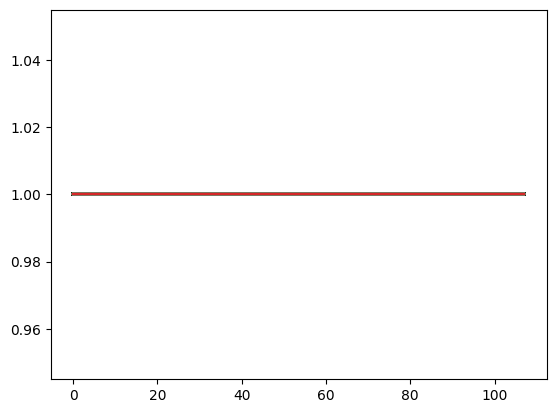

In [101]:
plt.plot(csp.attenuation_matrix)

In [154]:

sp.params['dust2'] = 0.5
sp.params['dust1'] = 0.0
sp.params['dust_index'] = -0.7

fit_params = {'tau_pow': 0.0, 'alpha': 1.0, 'diffuse_params': {'tau_kc': 0.5, 'dust_index': -0.7}}


wave, spec_fsps = sp.get_spectrum(tage=13.8) 

plt.figure(figsize=(20/3, 3))
plt.plot(csp.wave, fnu2flam(csp.wave, csp.get_spectrum(dust_params=fit_params)*1e-23*3631), lw =2, label='Composite Spectrum', color='blue')
plt.plot(wave, fnu2flam(wave, spec_fsps*1e-23*3631), label='FSPS Spectrum', lw=0.5, color='red', linestyle='--')
plt.yscale('log')
plt.xlim(0, 50000)
plt.ylim(1e-16, 10**-13)
plt.title('Composite Spectrum from CSP with Bimodal SFH')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux (erg/s/cm²/Å)')
plt.show()

TypeError: CSPBasis.get_spectrum_dustfree() got an unexpected keyword argument 'dust_params'

<Figure size 666.667x300 with 0 Axes>

In [ ]:
attenuation = jnp.stack(attenuation)  # shape: (n_bins, n_lambda)
ages = jnp.asarray(ages)
bin_edges = jnp.asarray(bin_edges)    # shape: (n_bins, 2)
# Find bin index for each age
starts = bin_edges[:, 0]
ends = bin_edges[:, 1]
in_bin = (ages[:, None] >= starts[None, :]) & (ages[:, None] < ends[None, :])
bin_idx = jnp.argmax(in_bin, axis=1)  # pick first True in each row
# Gather curves
attenuation_matrix = attenuation[bin_idx]  # shape: (n_ages, n_lambda)